In [2]:
import os

# Limit threading for Dedalus and NumExpr
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_MAX_THREADS"] = "1"

# Now import Dedalus


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import dedalus.public as d3

import os;import shutil;from pathlib import Path
# SNAPSHOTS_DIR = "/scratch/cimes/ml1994/Held_Suarez_model/earth_zonally_symmetric/data/"
SNAPSHOTS_DIR = "/scratch/cimes/ml1994/Held_Suarez_model/HS94_forcing_zonally_symmetric/data/"
# SNAPSHOTS_DIR = "/scratch/cimes/ml1994/Held_Suarez_model/asymmetric_HS94/data/"
# SNAPSHOTS_DIR = "/scratch/cimes/ml1994/Held_Suarez_model/sharp_monopole_asymm_HS94/data/"
# SNAPSHOTS_DIR = "/scratch/cimes/ml1994/Held_Suarez_model/dipole_asymmetric_HS94/data/"
# SNAPSHOTS_DIR = "/scratch/cimes/ml1994/Held_Suarez_model/HS94_symm_plus_split_forcing/data/"


import warnings; import sys

import h5py

import cartopy.crs as ccrs
import cartopy.util as cutil


In [20]:
SNAPSHOTS_DIR+'%s/%s_%s.h5'%('a','a',1)

'/scratch/cimes/ml1994/Held_Suarez_model/HS94_forcing_zonally_symmetric/data/a/a_1.h5'

In [21]:
color = 0

# omega_earth = 7.29e-5
# radius_earth = 6.371e6
# cp_earth = 1006
# dtheta_earth = 40

# theta0_earth = 315   # K global mean temp (from Lee 2005)

# tau_drag = (10 * 24 * 3600)
# tau_rad = (30 * 24 * 3600)

# Ro_T = (cp_earth * dtheta_earth) * (2 * omega_earth * radius_earth)**-2

# tau_rad_nondim = 2 * omega_earth * tau_rad  # tau_rad_nondims[color%3]  # thermal relaxation timescale [s^-1]

# E = (2 * omega_earth * tau_drag)**-1  

# # Parameters
# Nphi = 128; Ntheta = 64; resolution='T64'
# #Nphi = 64; Ntheta = 32; resolution='T32'
# dealias = (3/2, 3/2)
# dtype = np.float64

# # Set Parameters
# N=10   # number of layers
# #Ro_T = 1.
# # E = 0.02    # Ekman number 1 / 2 \Omega \tau_{drag}
# #tau_rad_nondim = 30
# mu = 1/6     #  Is this S = \Theta_{1} - \Theta_{2}?

omega_earth = 7.29e-5
radius_earth = 6.371e6
cp_earth = 1006

T_ref = 315
T_min = 200
dthetaH = 60
dthetaV = 10
mu = dthetaV/dthetaH


tau_drag = (1 * 24 * 3600)
tau_rad = (40 * 24 * 3600)

Ro_T = (cp_earth * dthetaH) * (2 * omega_earth * radius_earth)**-2

tau_rad_nondim = 2 * omega_earth * tau_rad  # tau_rad_nondims[color%3]  # thermal relaxation timescale [s^-1]

E = (2 * omega_earth * tau_drag)**-1    # Ekman number 1 / 2 \Omega \tau_{drag}

# Parameters
Nphi = 128; Ntheta = 64; resolution='T64'
#Nphi = 64; Ntheta = 32; resolution='T32'
dealias = (3/2, 3/2)
dtype = np.float64

# Set Parameters
N=10   # number of layers



linear=False
timestep = 1e-2



In [22]:
lat_forcing = lambda lat: np.cos(lat)**2; lattyp=''

lontyp = 'axi'

if lontyp=='locked':
    lon_forcing = lambda lon: np.cos(lon)*(np.cos(lon)>=0.)
elif lontyp=='axi':
    lon_forcing = lambda lon: 1/np.pi*lon**0
elif lontyp=='semilocked':
    lon_forcing = lambda lon: 1/np.pi*lon**0 + 0.5 * np.cos(lon)
elif lontyp=='semilocked2':
    lon_forcing = lambda lon: 1/np.pi*lon**0 + 0.5 * np.cos(lon) + 2/(3*np.pi) * np.cos(2*lon)
elif lontyp=='halfcoslon':
    lon_forcing = lambda lon: 0.5*np.cos(lon)
elif lontyp=='coslon':
    lon_forcing = lambda lon: 0.5*np.cos(lon)
else:
    raise ValueError("wrong input argument")

if linear:
    ext='_linear'
else:
    ext=''







In [23]:
coords = d3.S2Coordinates('phi', 'theta')



In [24]:


snapshot_id = 'snapshots_N%ilevelnondim_%s_%s%s_%.2f_%.2f_%i_%.2f%s'%(N,resolution,lontyp,lattyp,Ro_T,E,tau_rad_nondim,mu,ext)
snapshot_id = snapshot_id.replace('.','p')

snapshot_path = str(Path(SNAPSHOTS_DIR) / snapshot_id)

In [25]:
#########################################

# diagnostic parameters
kappa=2/7
Pis = (np.arange(N)/N + 1/(2*N))**kappa
# Pis = np.arange(0.1,1,0.06)
deltasigma = 1/N

# Ekman vertical distribution
# Eks = np.zeros(N)
# Eks[-1] = E
# Eks[-N//2:] = E #/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\

# Example: linear vertical profile of damping (s^-1)
Eks = np.zeros(N)
E_surface = E  # e.g., tau_fric_surface = 1 day
E_top     = 0.0                     # no damping at top

# Linear profile from surface (bottom, index -1) to top (index 0)
for i in range(N):
    # fraction from bottom layer
    frac = (N-1 - i) / (N-1)  # frac = 1 at bottom (-1), 0 at top (0)
    Eks[i] = E_top + frac * (E_surface - E_top)

hyperdiff_degree = 4; nu = 5e-8#/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\/!\
if Ro_T>2 and tau_rad_nondim<=10:
    print("Enhancing hyperdiffusivity")
    nu*=4.
# For vertical diffusion: - gamma*(u{b}+u{c}-2*u{a})/deltasigma**2



In [12]:

coords = d3.S2Coordinates('phi', 'theta')
dist = d3.Distributor(coords, dtype=dtype) # ,comm=newcomm)#
full_basis = d3.SphereBasis(coords, (Nphi, Ntheta), radius=1, dealias=dealias, dtype=dtype)

phi, theta = dist.local_grids(full_basis)
lat = np.pi / 2 - theta + 0*phi
lon = phi-np.pi

meanthetaEs = np.zeros(N)
sample_lat = np.linspace(-np.pi/2,np.pi/2,201)[:,None]
sample_lon = np.linspace(-np.pi,np.pi,401)[None,:]


In [13]:
# Fields
unames      = ["u%i"%i for i in range(1,N+1)]
thetanames  = ["theta%i"%i for i in range(1,N+1)]
thetaEnames = ["thetaE%i"%i for i in range(1,N+1)]

us      = [dist.VectorField(coords, name=name, bases=full_basis) for name in unames     ]
thetas  = [dist.      Field(        name=name, bases=full_basis) for name in thetanames ]
thetaEs = [dist.      Field(        name=name, bases=full_basis) for name in thetaEnames]
Phi1   = dist.Field(name='Phi1'  , bases=full_basis)
tau = dist.Field(name='tau')


In [78]:


# for i in range(N):
#     # thetaEs[i]['g'] = (1-mu*np.log(Pis[i])) * lat_forcing(lat)*lon_forcing(lon) * np.pi
#     # meanthetaEs[i] = np.mean( np.cos(sample_lat) * ( (1-mu*np.log(Pis[i])) *lat_forcing(sample_lat)*lon_forcing(sample_lon) ) * np.pi/2 )

#     thetaEs[i]['g'] = (1-mu*np.log(Pis[i])) * np.cos(lat)**2 * lon**0
#     meanthetaEs[i] = np.mean( np.cos(sample_lat) * (1-mu*np.log(Pis[i])) * np.cos(sample_lat)**2 * sample_lon**0)

#     # thetaEs[i]['g'] = (1/np.pi * lon**0) * (np.maximum(0.0, 1 - np.sin(lat)**2 - mu * np.log(Pis[i]) * np.cos(lat)**2))  # format is vertical structure * lon forcing * lat forcing
#     # meanthetaEs[i] = np.mean(np.cos(sample_lat) * (1/np.pi * sample_lon**0) * (np.maximum(200, 315 - 60*np.sin(sample_lat)**2 - mu * 10*np.log(Pis[i]) * np.cos(sample_lat)**2 / (2/7))) * np.pi/2)



kappa=2/7
Pis = (np.arange(N)/N + 1/(2*N))**kappa

T_ref = 315
T_min = 190
dthetaH = 60
dthetaV = 10
mu = dthetaV/dthetaH

Teqs_bar = np.zeros((lat.shape[1], N))
Teqs_bar_orig = np.zeros((lat.shape[1], N))

# phi, theta = dist.local_grids(full_basis)
# lat = np.pi / 2 - theta + 0*phi
# lon = phi-np.pi

# meanthetaEs = np.zeros(N)
# sample_lat = np.linspace(-np.pi/2,np.pi/2,201)[:,None]
# sample_lon = np.linspace(-np.pi,np.pi,401)[None,:]

# setting radiative equilibrium theta field
n_deg = 2
alpha_heat = ((Pis - Pis[0]) / (Pis[-1] - Pis[0]))**n_deg # (1 + 2* Pis**(1/kappa)) / 3 # 
alpha = np.clip((Pis - Pis[2]) / (Pis[-1] - Pis[2]), 0, 1)**n_deg # (1 + 2* Pis**(1/kappa)) / 3 # 

A_heat = 1.0 * alpha_heat
A_cool = - 0.83 * alpha

phi_heating = np.deg2rad(10)
phi_cooling = np.deg2rad(45)


for i in range(N):
    Teq = ((T_ref/dthetaH - np.sin(lat)**2 - mu * np.log(Pis[i])*np.cos(lat)**2 / kappa)* Pis[i]) * lon**0

    Teq += A_heat[i] * (np.cos(0.5*np.pi*lat/phi_heating)**2) * (np.abs(lat) <= phi_heating)

    Teq += A_cool[i] * np.cos(0.5 * np.pi * (1.0 * np.pi/2 - np.abs(lat)) / (1.0 * np.pi/2 - phi_cooling))**2 * (np.abs(lat) >= phi_cooling)    

    Teq = np.maximum(T_min/dthetaH, Teq)
    
    Teqs_bar[:,i] = np.mean(Teq, axis=0)
    
    thetaEs[i]['g'] = Teq / Pis[i]
    meanthetaEs[i] = np.mean(np.cos(sample_lat) * (1/np.pi * sample_lon**0) * np.maximum(T_min/dthetaH,(T_ref/dthetaH - np.sin(sample_lat)**2 - mu * np.log(Pis[i])*np.cos(sample_lat)**2 / kappa)* Pis[i]) / Pis[i])



In [79]:


for i in range(N):
    # thetaEs[i]['g'] = (1 - mu*np.log(Pis[i])/kappa) * (1 - np.sin(lat)**2) * lon**0
    Teq = np.maximum(T_min/dthetaH, (T_ref/dthetaH - np.sin(lat)**2 - mu * np.log(Pis[i])*np.cos(lat)**2 / kappa)* Pis[i]) * lon**0

    Teqs_bar_orig[:,i] = np.mean(Teq, axis=0)
    
    # thetaEs[i]['g'] = Teq / Pis[i]
    # meanthetaEs[i] = np.mean(np.cos(sample_lat) * (1/np.pi * sample_lon**0) * np.maximum(T_min/dthetaH,(T_ref/dthetaH - np.sin(sample_lat)**2 - mu * np.log(Pis[i])*np.cos(sample_lat)**2 / kappa)* Pis[i]) / Pis[i])



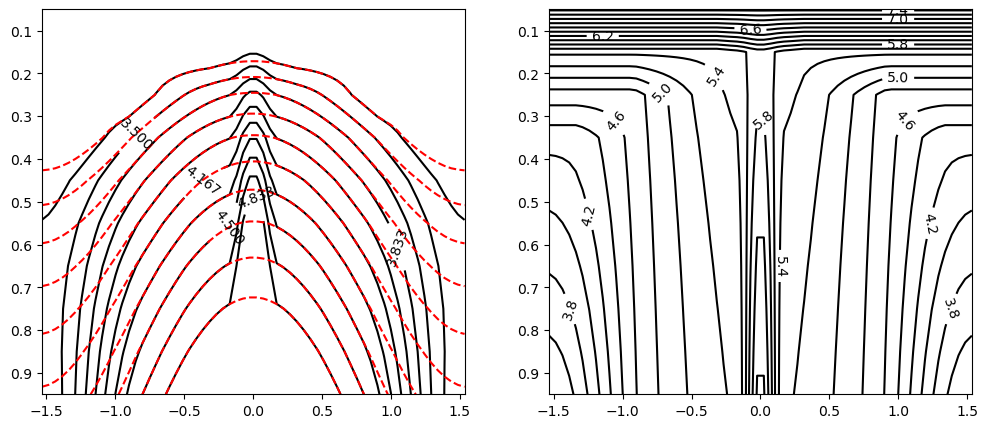

In [80]:
theta_bar = np.zeros((lat.shape[1], N))

for i in range(N):
    theta_bar[:,i] = np.mean(thetaEs[i]['g'], 0)

Teq_levels = np.arange(190, 300, 10) / dthetaH
    
fig, ax = plt.subplots(1,2, figsize=(12,5))

cl1 = ax[0].contour(lat[0, :], Pis**(1/kappa), np.transpose(Teqs_bar), levels=Teq_levels, colors="black")

plt.clabel(cl1, cl1.levels[::2], inline=True, fontsize=10)

cl1b = ax[0].contour(lat[0, :], Pis**(1/kappa), np.transpose(Teqs_bar_orig), levels=Teq_levels, colors="red", linestyles="dashed")

ax[0].invert_yaxis()

cl2 = ax[1].contour(lat[0, :], Pis**(1/kappa),  np.transpose(theta_bar), levels=20, colors="black")

plt.clabel(cl2, cl2.levels[::2], inline=True, fontsize=10)

ax[1].invert_yaxis()

In [233]:
alpha

array([0.        , 0.27949386, 0.44252003, 0.56365898, 0.66204776,
       0.7458432 , 0.81936052, 0.88518788, 0.94501213, 1.        ])

In [64]:
# zonally asymmetric thermal forcing (Gaussian)

for i in range(N):
    # --- Original Held–Suarez zonal-mean Teq ---
    Teq_zonal = np.maximum(
        T_min/dthetaH,
        (T_ref/dthetaH
         - np.sin(lat)**2
         - mu * np.log(Pis[i]) * np.cos(lat)**2 / kappa
        ) * Pis[i]
    )

    # ===============================
    # ZONALLY LOCALIZED GAUSSIAN FORCING
    # ===============================

    # --- Longitude Gaussian ---
    lon0 = 0.0                      # center (radians)
    lon_width = np.deg2rad(30.0)   # width (~20–40 deg works well)

    # Wrap-safe longitude difference (important if lon is periodic)
    dlon = np.mod(lon - lon0 + np.pi, 2*np.pi) - np.pi
    G_lon = np.exp(-(dlon**2) / (2 * lon_width**2))

    # --- Latitude structure (midlatitude peaks, both hemispheres) ---
    phi0 = np.deg2rad(45.0)
    width = np.deg2rad(20.0)

    F_phi = (
        np.exp(-((lat - phi0)**2) / (2 * width**2)) +
        np.exp(-((lat + phi0)**2) / (2 * width**2))
    )

    # --- Vertical structure (strong near surface, weak aloft) ---
    sigma = Pis[i] / Pis[-1]   # ~1 at surface (i=9), small at top (i=0)

    A0 = 0.15 * (T_ref/dthetaH)   # amplitude scale (tune 0.05–0.3)
    A_p = A0 * sigma**2           # decay with height

    # --- Add perturbation ---
    Teq = Teq_zonal + A_p * F_phi * G_lon

    # --- Convert to theta ---
    thetaEs[i]['g'] = Teq / Pis[i]

    # --- Zonal mean (use ONLY zonal-mean part to avoid bias) ---
    Teq_mean = np.maximum(
        T_min/dthetaH,
        (T_ref/dthetaH
         - np.sin(sample_lat)**2
         - mu * np.log(Pis[i]) * np.cos(sample_lat)**2 / kappa
        ) * Pis[i]
    )

    meanthetaEs[i] = np.mean(
        np.cos(sample_lat) * (1/np.pi) * (Teq_mean / Pis[i])
    )


In [135]:
for i in range(N):

    # --- Original Held–Suarez zonal-mean Teq ---
    Teq_zonal = np.maximum(
        T_min/dthetaH,
        (T_ref/dthetaH
         - np.sin(lat)**2
         - mu * np.log(Pis[i]) * np.cos(lat)**2 / kappa
        ) * Pis[i]
    )

    # define dipole
    # add_dipole(width_broad, width_narrow, amp_broad, amp_narrow, phi0, lat_width)
    dip = add_dipole(np.deg2rad(40.0), np.deg2rad(20.0), (30/dthetaH), (0.0/dthetaH), np.deg2rad(40.0), np.deg2rad(10.0));
    
    # --- Apply perturbation ---
    Teq = Teq_zonal + dip

    # --- Convert to theta ---
    thetaEs[i]['g'] = Teq / Pis[i]

    # --- Zonal mean (keep purely zonal HS state) ---
    Teq_mean = np.maximum(
        T_min/dthetaH,
        (T_ref/dthetaH
         - np.sin(sample_lat)**2
         - mu * np.log(Pis[i]) * np.cos(sample_lat)**2 / kappa
        ) * Pis[i]
    )

    meanthetaEs[i] = np.mean(
        np.cos(sample_lat) * (1/np.pi) * (Teq_mean / Pis[i])
    )




In [129]:
# dipole

for i in range(N):

    # --- Original Held–Suarez zonal-mean Teq ---
    Teq_zonal = np.maximum(
        T_min/dthetaH,
        (T_ref/dthetaH
         - np.sin(lat)**2
         - mu * np.log(Pis[i]) * np.cos(lat)**2 / kappa
        ) * Pis[i]
    )

    # ===============================
    # ASYMMETRIC WAVENUMBER-2 GAUSSIAN FORCING
    # ===============================

    # --- Centers (two basins, each with + and - lobe) ---
    lon_pos_1 = 0.0           # Basin A (e.g., "Pacific")
    lon_neg_1 = np.pi/2

    lon_pos_2 = np.pi         # Basin B (e.g., "Atlantic")
    lon_neg_2 = 3*np.pi/2

    # --- Widths (key asymmetry!) ---
    width_broad = np.deg2rad(35.0)   # broader basin
    width_narrow = np.deg2rad(20.0)  # sharper basin

    # --- Amplitudes (optional asymmetry) ---
    amp_broad = 1.0
    amp_narrow = 1.0

    # Wrap-safe longitude difference
    def dlon_wrap(lon, lon0):
        return np.mod(lon - lon0 + np.pi, 2*np.pi) - np.pi

    # --- Build lobes ---
    G_pos1 = amp_broad * np.exp(-(dlon_wrap(lon, lon_pos_1)**2) / (2 * width_broad**2))
    G_neg1 = amp_broad * np.exp(-(dlon_wrap(lon, lon_neg_1)**2) / (2 * width_broad**2))

    G_pos2 = amp_narrow * np.exp(-(dlon_wrap(lon, lon_pos_2)**2) / (2 * width_narrow**2))
    G_neg2 = amp_narrow * np.exp(-(dlon_wrap(lon, lon_neg_2)**2) / (2 * width_narrow**2))

    # --- Combine into + - + - pattern ---
    G_lon = (G_pos1 - G_neg1) + (G_pos2 - G_neg2)

    # Normalize to keep amplitude controlled
    G_lon = G_lon / np.max(np.abs(G_lon))

    # --- Latitude structure ---
    phi0 = np.deg2rad(45.0)
    width = np.deg2rad(20.0)

    F_phi = (
        np.exp(-((lat - phi0)**2) / (2 * width**2)) +
        np.exp(-((lat + phi0)**2) / (2 * width**2))
    )

    # --- Vertical structure ---
    sigma = Pis[i] / Pis[-1]

    A0 = 0.15 * (T_ref/dthetaH)
    A_p = A0 * sigma**5

    # --- Apply perturbation ---
    Teq = Teq_zonal + A_p * F_phi * G_lon

    # --- Convert to theta ---
    thetaEs[i]['g'] = Teq / Pis[i]

    # --- Zonal mean (unchanged) ---
    Teq_mean = np.maximum(
        T_min/dthetaH,
        (T_ref/dthetaH
         - np.sin(sample_lat)**2
         - mu * np.log(Pis[i]) * np.cos(sample_lat)**2 / kappa
        ) * Pis[i]
    )

    meanthetaEs[i] = np.mean(
        np.cos(sample_lat) * (1/np.pi) * (Teq_mean / Pis[i])
    )

In [120]:
def add_dipole(width_broad, width_narrow, amp_broad, amp_narrow, phi0, lat_width):
    # width_broad = np.deg2rad(60.0)   # 60 degrees
    # width_narrow = np.deg2rad(25.0)  # 20 degrees

    # divide the globe into two "sectors" based on the ratio of widths
    total_w = width_broad + width_narrow
    sector_broad = (width_broad / total_w) * (2 * np.pi)
    sector_narrow = (width_narrow / total_w) * (2 * np.pi)

    # --- Define Centers within those Sectors ---
    # We want the positive and negative lobes to be 'evenly spaced' within their sector.
    # That means placing them at 1/4 and 3/4 marks of their assigned territory.

    broad_center = sector_broad/2
    narrow_center = sector_broad + sector_narrow/2
    
    # Basin 1: Broad (Centered around lon = 0)
    # Territory: [-sector_broad/2, +sector_broad/2]
    lon_pos_1 = broad_center - sector_broad / 4
    lon_neg_1 = broad_center + sector_broad / 4

    # Basin 2: Narrow (Centered around lon = pi)
    # Territory: [pi - sector_narrow/2, pi + sector_narrow/2]
    lon_pos_2 = narrow_center - sector_narrow / 4
    lon_neg_2 = narrow_center + sector_narrow / 4

    # --- Amplitudes ---
    # amp_broad = 1.5
    # amp_narrow = 1.0

    # --- Build the Forcing (No global normalization to protect amplitudes) ---
    def dlon_wrap(lon, lon0):
        return np.mod(lon - lon0 + np.pi, 2*np.pi) - np.pi

    G_lon = (amp_broad * np.exp(-(dlon_wrap(lon, lon_pos_1)**2) / (2 * width_broad**2)) -
             amp_broad * np.exp(-(dlon_wrap(lon, lon_neg_1)**2) / (2 * width_broad**2)) +
             amp_narrow * np.exp(-(dlon_wrap(lon, lon_pos_2)**2) / (2 * width_narrow**2)) -
             amp_narrow * np.exp(-(dlon_wrap(lon, lon_neg_2)**2) / (2 * width_narrow**2)))

    # --- Latitude structure ---
    F_phi = (
        np.exp(-((lat - phi0)**2) / (2 * lat_width**2)) +
        np.exp(-((lat + phi0)**2) / (2 * lat_width**2))
    )

    # --- Vertical structure ---
    sigma = Pis[i] / Pis[-1]

    A0 = 1.0 # 0.15 * (T_ref/dthetaH)
    A_p = A0 * sigma**4

    return A_p * F_phi * G_lon



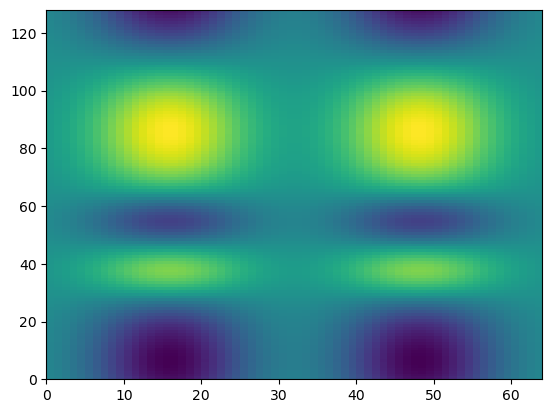

In [119]:
plt.pcolormesh(dip)

In [106]:
width_broad = np.deg2rad(60.0)
width_narrow = np.deg2rad(40.0)

total_w = width_broad + width_narrow
sector_broad = (width_broad / total_w) * (2 * np.pi)
sector_narrow = (width_narrow / total_w) * (2 * np.pi)


In [109]:
sector_narrow + sector_broad


np.float64(6.283185307179586)

In [14]:
i=0

snapshot_path + snapshot_id + '_s1_p' + str(i) + '.h5'

'/scratch/cimes/ml1994/Held_Suarez_model/dipole_asymmetric_HS94/data/snapshots_N10levelnondim_T64_axi_0p07_0p08_503_0p17snapshots_N10levelnondim_T64_axi_0p07_0p08_503_0p17_s1_p0.h5'

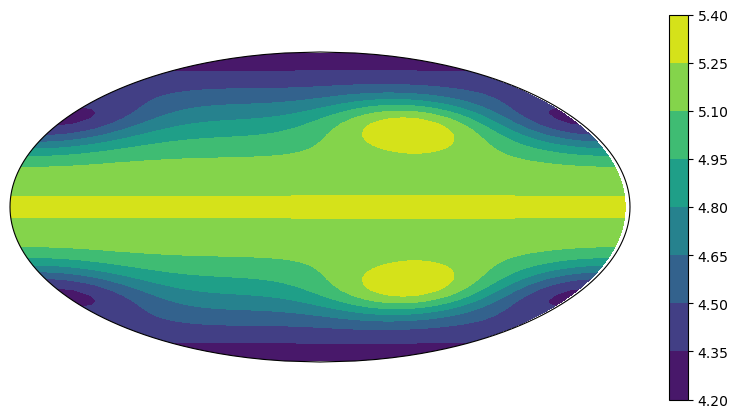

In [137]:
# u_data shape is nt?, 2 horizontal components, Nphi, Ntheta/Nproc_per_run
# lon2d, lat2d = np.meshgrid()


# cdata, clon2d, clat2d = cutil.add_cyclic(thetaEs[-1]['g'] - np.mean(thetaEs[9]['g'] , axis=0), lon * np.ones((1, 64))  * (180/np.pi), lat * (180/np.pi))
cdata, clon2d, clat2d = cutil.add_cyclic(thetaEs[-1]['g'], lon * np.ones((1, 64))  * (180/np.pi), lat * (180/np.pi))


# plt.pcolormesh(lat, lon, u_data[-1,0,:,:])
def main():
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mollweide())

    # ax.contourf(lon * np.ones((1, 64))  * (180/np.pi), lat * (180/np.pi),
    #             u_data[-1,0,:,:],
    #             transform=ccrs.PlateCarree()) # ,
                # cmap='nipy_spectral')
    
    cf1 = ax.contourf(clon2d, clat2d,
                cdata,
                transform=ccrs.PlateCarree())
    
    # ax.coastlines()
    plt.colorbar(cf1)
    
    ax.set_global()
    plt.show()


if __name__ == '__main__':
    main()


In [24]:
u_dims = cp_earth * dthetaH / (2 * omega_earth * radius_earth)

# def define_u_omega(u_dims, level_str):
#     for i in np.arange(0,8):
#         # Open .h5 file
#         snapshot_file = snapshot_path + '/' + snapshot_id + '_s1/' + snapshot_id + '_s1_p' + str(i) + '.h5'
#         with h5py.File(snapshot_file, 'r') as f:
#             # print("Keys in the snapshot:", list(f.keys()))
    
#             if i==0:
#                 # velocity 
#                 u_data = f['tasks']['u'+level_str][:] * u_dims  #
                
#                 # omega1
#                 omega_data = f['tasks']['omega'+level_str][:]
#             else:
#                 # velocity 
#                 u_temp = f['tasks']['u'+level_str][:] * u_dims  #
                
#                 # omega1
#                 omega_temp = f['tasks']['omega'+level_str][:]
    
#                 u_data = np.append(u_data, u_temp, axis=3)
#                 omega_data = np.append(omega_data, omega_temp, axis=2)

#         return u_data, omega_data

# u_data, omega_data = define_u_omega(u_dims, '1')

# print("u shape:", u_data.shape)
# print("omega1 shape:", omega_data.shape)

In [37]:
n_level = 1   # profile from surface (bottom, index -1) to top (index 0)

def define_u_of_t(n_level):
    snapfile_s1 = snapshot_path + '/' + snapshot_id + '_s1.h5'
    f_s1 = h5py.File(snapfile_s1, 'r')['tasks']['u'+str(n_level)]
    
    # snapfile_s2 = snapshot_path + '/' + snapshot_id + '_s2.h5'
    # f_s2 = h5py.File(snapfile_s2, 'r')['tasks']['u'+str(n_level)]
    
    # u = np.concatenate((f_s1[:,0,:,:], f_s2[:,0,:,:]), axis=0)

    return f_s1[:,0,:,:]

u1 = define_u_of_t(1)

u3 = define_u_of_t(3)

u5 = define_u_of_t(5)

u10 = define_u_of_t(10)


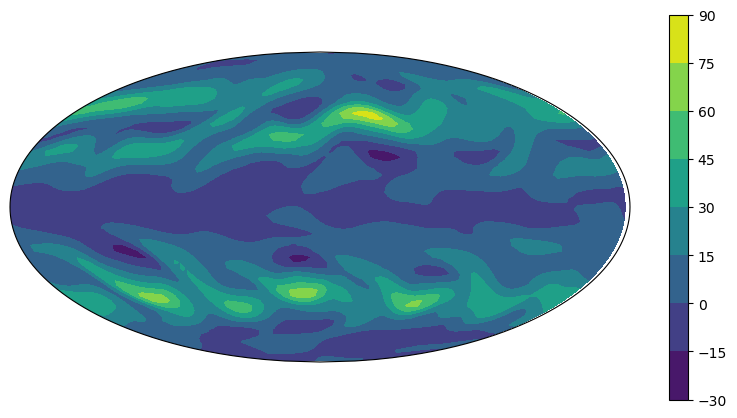

In [70]:
# u_data shape is nt?, 2 horizontal components, Nphi, Ntheta/Nproc_per_run
# lon2d, lat2d = np.meshgrid()

cdata, clon2d, clat2d = cutil.add_cyclic(u3[-1,:,:] * u_dims, lon * np.ones((1, 64))  * (180/np.pi), lat * (180/np.pi))


# plt.pcolormesh(lat, lon, u_data[-1,0,:,:])
def main():
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mollweide())

    # ax.contourf(lon * np.ones((1, 64))  * (180/np.pi), lat * (180/np.pi),
    #             u_data[-1,0,:,:],
    #             transform=ccrs.PlateCarree()) # ,
                # cmap='nipy_spectral')
    
    cf1 = ax.contourf(clon2d, clat2d,
                cdata,
                transform=ccrs.PlateCarree())
    
    # ax.coastlines()
    plt.colorbar(cf1)
    
    ax.set_global()
    plt.show()


if __name__ == '__main__':
    main()


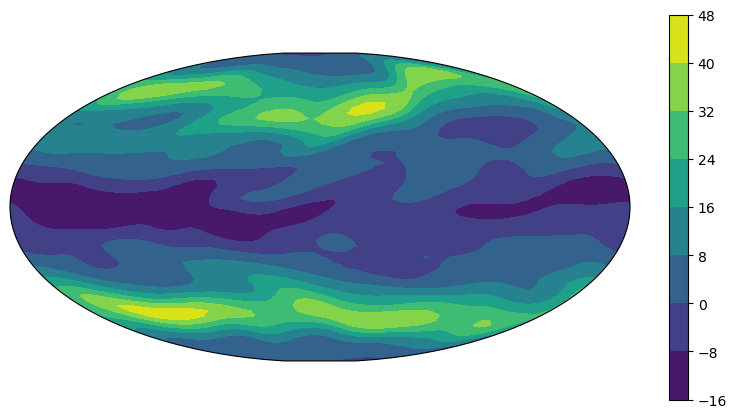

In [43]:
from cartopy.util import add_cyclic_point

lon_deg = np.asarray(lon).squeeze() * 180/np.pi
lat_deg = np.asarray(lat[0,:]).squeeze() * 180/np.pi


data = u1[-11,:,:]   # shape (lat, lon)

def plot_global_field(lon_deg, lat_deg, data, u_dim=1):
    cdata, clon = add_cyclic_point(np.transpose(data * u_dim), coord=lon_deg)
    
    clon2d, clat2d = np.meshgrid(clon, lat_deg)
    
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mollweide())
    
    
    cf1 = ax.contourf(
        clon2d,
        clat2d,
        cdata,
        transform=ccrs.PlateCarree()
    )
    
    plt.colorbar(cf1)

plot_global_field(lon_deg, lat_deg, data, u_dim=u_dims)


In [59]:
thetaEs[9]['g'].shape



(128, 64)

In [49]:
theta10_xy = np.zeros((lat.shape[1], N))

for i in range(N):
    theta_bar[:,i] = np.mean(thetaEs[i]['g'], 0)

(128, 64)

In [31]:
i=1

snapfile = snapshot_path + '/' + snapshot_id + '_s1.h5'
f = h5py.File(snapfile, 'r')['tasks']['u'+str(i)]

f.shape

(46, 2, 128, 64)

In [34]:
u_dims = cp_earth * dthetaH / (2 * omega_earth * radius_earth)

u_bar = np.zeros((64, 10))

for i in np.arange(1,11):
    snapfile = snapshot_path + '/' + snapshot_id + '_s1.h5'
    f = h5py.File(snapfile, 'r')['tasks']['u'+str(i)]

    # u_bar in space, only
    # u_bar[:, i-1] = np.mean(f[-4, 0, :, :], 0)
    
    # u_bar in time, too
    u_bar[:, i-1] = np.mean(np.mean(f[35:-1, 0, :, :], 0), 0)
    
    

u_bar.shape

(64, 10)

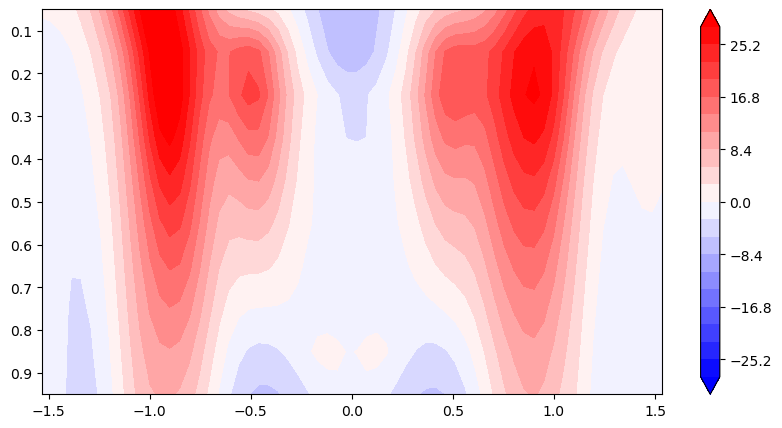

In [35]:
fig, ax = plt.subplots(1,1, figsize=(10,5))

pcu = ax.contourf(lat[0, :], Pis**(1/kappa), np.transpose(u_bar) * u_dims, levels=np.linspace(-28, 28, 21), cmap=plt.cm.bwr, extend='both') #, vmin=-40, vmax=40)

# plt.clabel(cl)

plt.gca().invert_yaxis()

cb = fig.colorbar(pcu, ax=ax)



In [109]:
sigmas = Pis**(1/kappa)

sigmas

array([0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95])

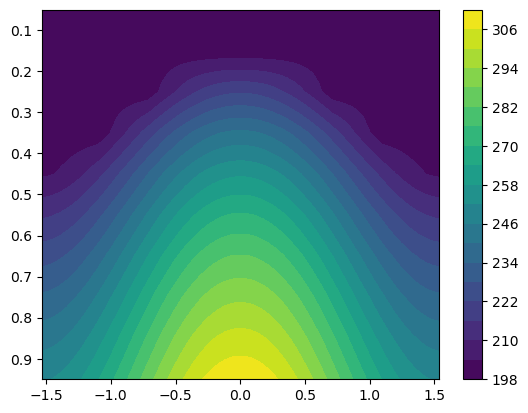

In [96]:
Teq_dim = dthetaH * Teqs_bar
sigma = Pis**(1/kappa)

cf1 = plt.contourf(lat[0,:], sigma, Teq_dim.T, levels=20)
plt.gca().invert_yaxis()
plt.colorbar(cf1)

In [126]:
dT_dphi = np.gradient(Teq_dim[:,-4], lat[0,:], axis=0)
thermal_shear = (287/(2*omega_earth*radius_earth)) * dT_dphi


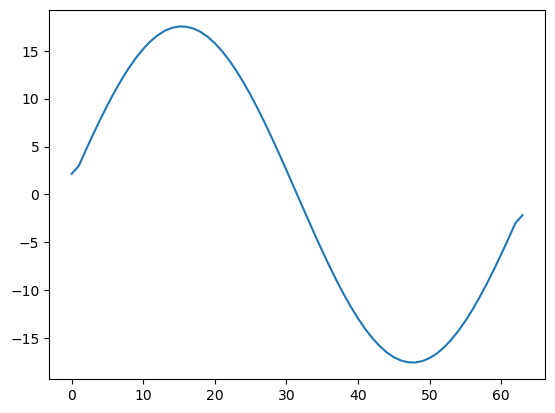

In [127]:
# plt.plot(Teq_dim[:,-1])

plt.plot(thermal_shear)

# animation

In [38]:
anim_dir = "/scratch/cimes/ml1994/Held_Suarez_model/analysis/figs/HS_anim/"

In [39]:
u3.shape

(46, 128, 64)

In [40]:
# for i in np.arange(0,u1.shape[0]):
#     plot_global_field(lon_deg, lat_deg, data, u_dim=u_dims)


In [41]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib.animation import FuncAnimation

def animate_global_field(lon_deg, lat_deg, data, u_dim=1, interval=200):
    """
    data: 3D array (time, lat, lon)
    """
    
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mollweide())

    # Initial frame
    cdata, clon = add_cyclic_point(np.transpose(data[0] * u_dim), coord=lon_deg)
    clon2d, clat2d = np.meshgrid(clon, lat_deg)

    levels = np.linspace(-40, 40, 21)  # 21 levels → steps of 4

    cf = ax.contourf(
        clon2d,
        clat2d,
        cdata,
        transform=ccrs.PlateCarree(),
        levels=levels,
        cmap='RdBu_r',
        extend='both')

    cb = fig.colorbar(cf, ax=ax, orientation='vertical')

    # fig.colorbar(cf, ax=ax, orientation='vertical')
    
    def update(frame):
        ax.clear()
        
        cdata, clon = add_cyclic_point(
            np.transpose(data[frame, :, :] * u_dim), coord=lon_deg
        )
        clon2d, clat2d = np.meshgrid(clon, lat_deg)
        
        cf = ax.contourf(
            clon2d,
            clat2d,
            cdata,
            transform=ccrs.PlateCarree(),
            levels=levels,
            cmap='RdBu_r',
            extend='both'
        )
        
        ax.set_title(f"Day: {4*(frame)}")

        return [] # cf.collections

    anim = FuncAnimation(
        fig,
        update,
        frames=data.shape[0],
        interval=interval,
        blit=False
    )
    
    return anim


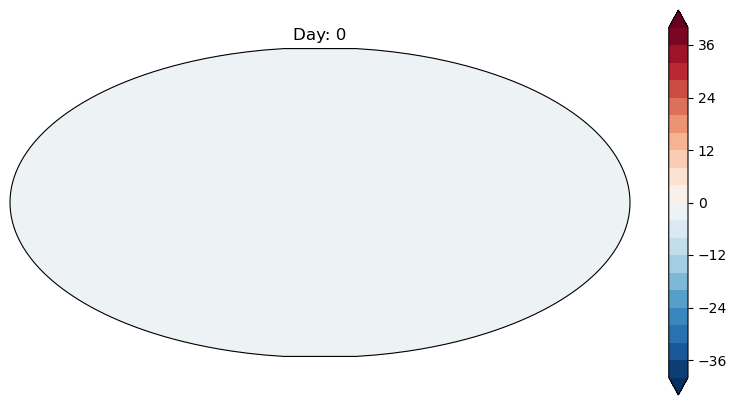

In [44]:
anim = animate_global_field(lon_deg, lat_deg, u3, u_dim=u_dims)
# plt.show()

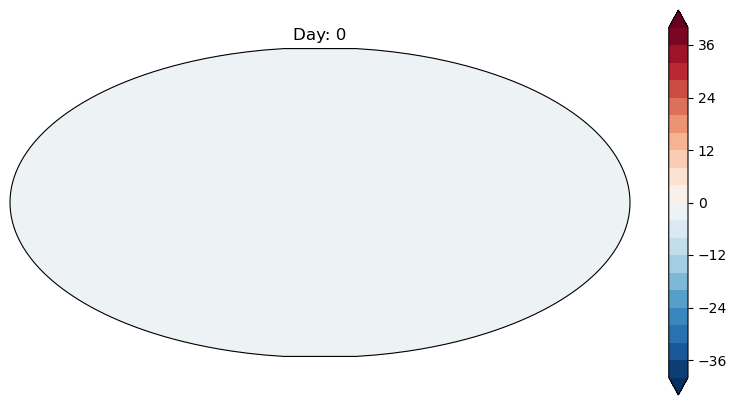

In [105]:
anim_u5 = animate_global_field(lon_deg, lat_deg, u5, u_dim=u_dims);


In [45]:
anim.save(anim_dir + "global_animation_u3_symm_split.gif", fps=5, dpi=150)

2026-04-02 10:44:57,495 matplotlib.animation 0/1 INFO :: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2026-04-02 10:44:57,498 matplotlib.animation 0/1 INFO :: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1500x750 -pix_fmt rgba -framerate 5 -i pipe: -filter_complex 'split [a][b];[a] palettegen [p];[b][p] paletteuse' -y /scratch/cimes/ml1994/Held_Suarez_model/analysis/figs/HS_anim/global_animation_u3_symm_split.gif


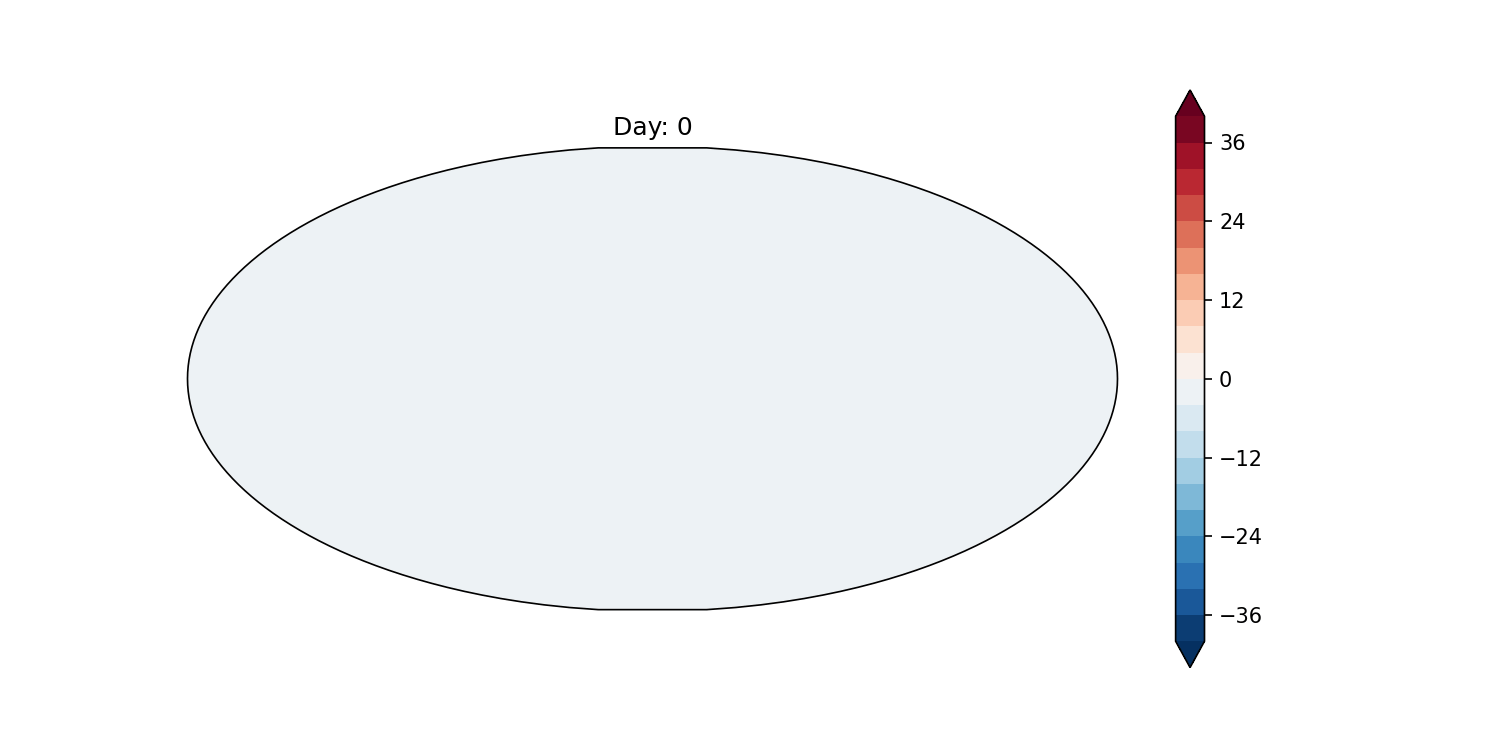

In [46]:
from IPython.display import Image

Image(anim_dir + "global_animation_u3_symm_split.gif")

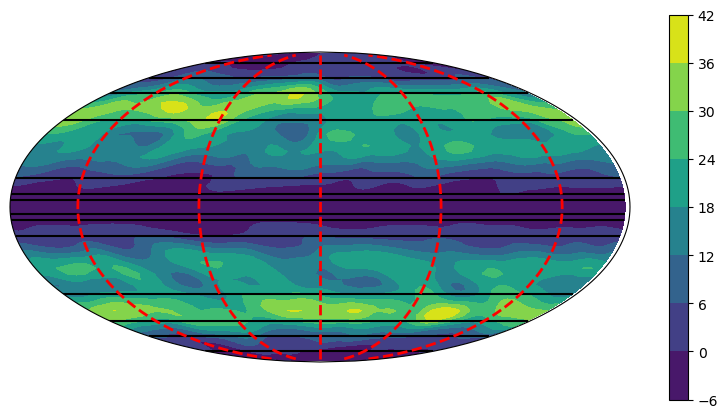

In [83]:
# time-mean of u

cdata, clon2d, clat2d = cutil.add_cyclic(np.mean(u3[36:-1, :, :], axis=0) * u_dims, lon * np.ones((1, 64))  * (180/np.pi), lat * (180/np.pi))

cdata_theta, clon2d_theta, clat2d_theta = cutil.add_cyclic(thetaEs[9]['g'], lon * np.ones((1, 64))  * (180/np.pi), lat * (180/np.pi))

# plt.pcolormesh(lat, lon, u_data[-1,0,:,:])
def main():
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mollweide())

    # ax.contourf(lon * np.ones((1, 64))  * (180/np.pi), lat * (180/np.pi),
    #             u_data[-1,0,:,:],
    #             transform=ccrs.PlateCarree()) # ,
                # cmap='nipy_spectral')
    
    cf1 = ax.contourf(clon2d, clat2d,
                cdata,
                transform=ccrs.PlateCarree())

    c1 = ax.contour(clon2d_theta, clat2d_theta,
                cdata_theta,
                transform=ccrs.PlateCarree(),
                colors='black')
    
    # ax.coastlines()
    plt.colorbar(cf1)

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                  linewidth=2, color='red', alpha=1.0, linestyle='--')
    gl.xlocator = mticker.FixedLocator(lon[lon_inds].flatten() * (180/np.pi)) # Specific longitudes
    gl.ylocator = mticker.FixedLocator([]) # This hides latitude lines
        
    ax.set_global()
    plt.show()


if __name__ == '__main__':
    main()




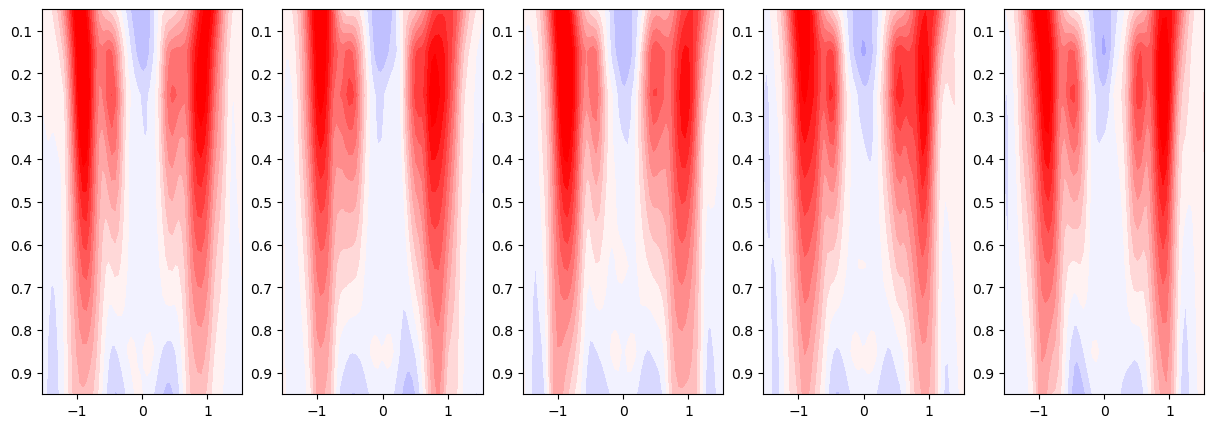

In [82]:
fig, ax = plt.subplots(1, 5, figsize=(15,5))

lon_inds = np.array([0, 25, 50, 75, 100]) + 14

for i in np.arange(0,5):

    # build u as function of z
    u_slice = np.zeros((64, 10))

    for j in np.arange(1,11):
        snapfile = snapshot_path + '/' + snapshot_id + '_s1.h5'
        f = h5py.File(snapfile, 'r')['tasks']['u'+str(j)]

        time_ind = -1
        
        u_slice[:, j-1] = np.mean(f[30:-1, 0, lon_inds[i], :], axis=0)
        
    # plot u
    pcu = ax[i].contourf(lat[0, :], Pis**(1/kappa), np.transpose(u_slice) * u_dims, levels=np.linspace(-28, 28, 21), cmap=plt.cm.bwr, extend='both') #, vmin=-40, vmax=40)

    ax[i].yaxis.set_inverted(True)
# plt.clabel(cl)
